# Notes nn - Predictors of recorded DS live births

- More boosting rounds


## Preparation


In [1]:
import joblib, optuna, os, shap
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
from lightgbm import early_stopping, log_evaluation
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
)
from sklearn.model_selection import train_test_split

import repl_utils, stats_utils, data_utils, ml_utils, plot_utils
from variables import Variables as vars

pd.options.mode.copy_on_write = True

plt.style.use("../../notebook.mplstyle")

os.makedirs("./output", exist_ok=True)

RANDOM_SEED = 47
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

N_CORES = joblib.cpu_count(only_physical_cores=True)

START_TIME = datetime.now()

OUTPUT_DIR = f"output/0010-predictors-10/{START_TIME:%Y%m%d-%H%M%S}"

os.makedirs(OUTPUT_DIR, exist_ok=True)

repl_utils.print_environment_info()

print(f"\n--------------------\nOutput directory: {OUTPUT_DIR}\n--------------------\n")

c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


-------------------- Environment Information --------------------
date: 2026-01-08T16:35:47.858320
platform: Windows-11-10.0.26220-SP0
platform_version: 10.0.26220
cpu: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
cores: 32
physical_cores: 24
ram: 127 GB
ram_available: 91 GB
cuda: True
cuda_device_count: 1
cuda_device_0: NVIDIA GeForce RTX 4070 Ti SUPER
python: 3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:10:00) [MSC v.1944 64 bit (AMD64)]
numpy: 2.3.5
pandas: 2.3.3
scipy: 1.16.3
sklearn: 1.8.0
lightgbm: 4.6.0
pytorch: 2.9.1
pymc: 5.27.0
pytensor: 2.36.3
arviz: 0.23.0

--------------------
Output directory: output/0010-predictors-10/20260108-163547
--------------------



### Options


In [2]:
START_YEAR = 2016
END_YEAR = 2024
# LightGBM threads
NUM_THREADS = N_CORES - 2
# Splitting data for training, validation and calibration
TRAINING_SPLIT = 0.8
VALIDATION_SPLIT = 0.2
# CALIBRATION_SPLIT = 1 - TRAINING_SPLIT - VALIDATION_SPLIT
#
NUM_BOOST_ROUND = 50000
EARLY_STOPPING_ROUNDS = 200
# True to search for hyperparameters
SELECT_HYPERPARAMETERS = True
#
OPTIMIZE_TRIALS = 200

SAVE_PLOTS = True

### Load data


In [3]:
df = data_utils.load_predictors_data(
    from_year=START_YEAR, to_year=END_YEAR, include_unknown=True
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Define initial feature set


In [4]:
numeric = [
    vars.YEAR,
    vars.DBWT,
    # vars.PWGT_R,
    vars.WTGAIN,
    vars.BMI,
    vars.MAGE_C,
    vars.FAGECOMB,
]

categorical = [
    # vars.DOB_MM,
    # vars.DOB_WK,
    # "dob_tt_pm",
    vars.BFACIL3,
    vars.SEX,
    vars.PRECARE,
    vars.GESTREC10,
    vars.RF_PDIAB,
    vars.RF_GDIAB,
    vars.RF_PHYPE,
    vars.RF_GHYPE,
    vars.RF_EHYPE,
    vars.RF_PPTERM,
    vars.RF_INFTR,
    vars.RF_FEDRG,
    vars.RF_ARTEC,
    # vars.NO_RISKS,
    vars.LD_INDL,
    vars.LD_AUGM,
    vars.ME_PRES,
    vars.DMETH_REC,
    vars.APGAR5,
    vars.APGAR10,
    vars.AB_AVEN1,
    vars.AB_AVEN6,
    vars.AB_NICU,
    vars.AB_SURF,
    vars.AB_ANTI,
    vars.AB_SEIZ,
    # vars.NO_ABNORM,
    vars.CA_ANEN,
    vars.CA_MNSB,
    vars.CA_CCHD,
    vars.CA_CDH,
    vars.CA_OMPH,
    vars.CA_GAST,
    vars.CA_LIMB,
    vars.CA_CLEFT,
    vars.CA_CLPAL,
    vars.CA_HYPO,
    vars.CA_DISOR,
    # vars.NO_CONGEN,
    vars.MEDUC,
    vars.MRACEHISP,
    vars.FEDUC,
    vars.FRACEHISP,
    vars.PAY_REC,
    vars.WIC,
]

features = categorical + numeric

X = df[features]
y = df["ca_down_c_p_n"].replace({pd.NA: 0, np.nan: 0}).astype(np.int32)

X[categorical] = X[categorical].astype("category")

### Split training, validation and calibration data


In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=(1-TRAINING_SPLIT), stratify=y, random_state=RANDOM_SEED
)

train_data = lgb.Dataset(
    X_train, label=y_train, categorical_feature=categorical, free_raw_data=False
)

valid_data = lgb.Dataset(
    X_valid,
    label=y_valid,
    categorical_feature=categorical,
    reference=train_data,
    free_raw_data=False,
)

In [6]:
neg_count_train = y_train[y_train == 0].count()
pos_count_train = y_train[y_train == 1].count()
# scale_pos_weight = neg_count_train / pos_count_train

neg_count_valid = y_valid[y_valid == 0].count()
pos_count_valid = y_valid[y_valid == 1].count()

print(
    f"Training set: {neg_count_train} negatives, {pos_count_train} positives, probability positive {pos_count_train / neg_count_train:.8f}"
)
print(
    f"Validation set: {neg_count_valid} negatives, {pos_count_valid} positives, probability positive {pos_count_valid / neg_count_valid:.8f}"
)

Training set: 26857135 negatives, 14247 positives, probability positive 0.00053047
Validation set: 6714284 negatives, 3562 positives, probability positive 0.00053051


In [7]:
base_params = {
    "objective": "binary",
    "metric": ["average_precision", "binary_logloss"],
    "boosting_type": "gbdt",
    "max_bin": 255,  # GPU 63/127; CPU 255
    # for now, we do not scale for better interpretability of outputs
    "scale_pos_weight": 1,
    "force_col_wise": True,
    "seed": RANDOM_SEED,
    "num_threads": NUM_THREADS,
    "verbosity": 1,
}

last_best_params = {
    "learning_rate": 0.009461164726049449,
    "num_leaves": 180,
    "min_data_in_leaf": 756,
    "min_gain_to_split": 0.9285634625013361,
    "feature_fraction": 0.9239582799934513,
    "bagging_fraction": 0.9185684081749333,
    "bagging_freq": 2,
    "lambda_l1": 0.0005836073944757167,
    "lambda_l2": 0.6142323696066677
}

## Hyperparameter tuning


In [8]:
def objective(trial):
    trial_params = {
        # required to change min_data_in_leaf across trials without rebuilding the Dataset
        "feature_pre_filter": False,
        # Speed / stability
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.75, log=True),
        # Tree complexity
        "num_leaves": trial.suggest_int("num_leaves", 32, 512, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 500, 10000, log=True),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 1.0),
        # Sampling
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        # Regularization
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
    }

    # Merge: base_params always present; trial_params override if same key exists
    params = {**base_params, **trial_params}

    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "average_precision")

    gbm = lgb.train(
        params,
        train_data,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[valid_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
            lgb.log_evaluation(period=10),
            pruning_cb,
        ],
    )

    # Best score on validation
    return gbm.best_score["valid_0"]["average_precision"]


if SELECT_HYPERPARAMETERS:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(),
        pruner=optuna.pruners.HyperbandPruner(),
    )

    study.optimize(objective, n_trials=OPTIMIZE_TRIALS)

    print(study.best_params, study.best_value)

    best = study.best_params
else:
    best = last_best_params

# Merge (best overrides base if there are collisions)
params = {**base_params, **best}
params["feature_pre_filter"] = True  # reset to default for final training

print("Parameters for training:")
for k, v in params.items():
    print(f'  "{k}": {v}')

[I 2026-01-08 16:36:30,203] A new study created in memory with name: no-name-af6a7d78-75a8-4210-9b4a-9509effd9821


[LightGBM] [Info] Number of positive: 14247, number of negative: 26857135
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 26871382, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000530 -> initscore=-7.541740
[LightGBM] [Info] Start training from score -7.541740
Training until validation scores don't improve for 200 rounds
[10]	valid_0's average_precision: 0.000457847	valid_0's binary_logloss: 0.578019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[20]	valid_0's average_precision: 0.00140551	valid_0's binary_logloss: 0.0228416
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more 

[I 2026-01-08 16:38:49,356] Trial 0 finished with value: 0.011210658967861147 and parameters: {'learning_rate': 0.6348730048607225, 'num_leaves': 205, 'min_data_in_leaf': 9930, 'min_gain_to_split': 0.16028816478805796, 'feature_fraction': 0.6794017282004325, 'bagging_fraction': 0.9484159767830771, 'bagging_freq': 2, 'lambda_l1': 8.258224315926036e-05, 'lambda_l2': 1.3284943278782089e-08}. Best is trial 0 with value: 0.011210658967861147.


Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0112107	valid_0's binary_logloss: 0.0506098
[LightGBM] [Info] Number of positive: 14247, number of negative: 26857135
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 26871382, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000530 -> initscore=-7.541740
[LightGBM] [Info] Start training from score -7.541740
Training until validation scores don't improve for 200 rounds
[10]	valid_0's average_precision: 0.0262617	valid_0's binary_logloss: 0.00404019
[20]	valid_0's average_precision: 0.0271672	valid_0's binary_logloss: 0.00390423
[30]	valid_0's average_precision: 0.027708	valid_0's binary_logloss: 0.00382451
[40]	valid_0's average_precision: 0.0283368	valid_0's binary_logloss: 0.00377102
[50]	valid_0's average_precision: 0.0290345	valid_0's binary_logloss: 0.00373375
[60]	valid_0's average_precision: 0.0293364	valid_0's binary_logloss: 0.00370649
[7

[I 2026-01-08 16:48:23,616] Trial 1 finished with value: 0.03164513358869646 and parameters: {'learning_rate': 0.018895207367976685, 'num_leaves': 68, 'min_data_in_leaf': 5122, 'min_gain_to_split': 0.4252361100370524, 'feature_fraction': 0.985889974161946, 'bagging_fraction': 0.8277963185706966, 'bagging_freq': 6, 'lambda_l1': 1.2169481749291132e-07, 'lambda_l2': 1.5194017630266273e-06}. Best is trial 1 with value: 0.03164513358869646.


...

[LightGBM] [Info] Number of positive: 14247, number of negative: 26857135
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 26871382, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000530 -> initscore=-7.541740
[LightGBM] [Info] Start training from score -7.541740
Training until validation scores don't improve for 200 rounds


[I 2026-01-08 21:59:22,583] Trial 198 pruned. Trial was pruned at iteration 3.


[LightGBM] [Info] Number of positive: 14247, number of negative: 26857135
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 26871382, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000530 -> initscore=-7.541740
[LightGBM] [Info] Start training from score -7.541740
Training until validation scores don't improve for 200 rounds


[I 2026-01-08 21:59:25,053] Trial 199 pruned. Trial was pruned at iteration 1.


{'learning_rate': 0.013228215202806008, 'num_leaves': 95, 'min_data_in_leaf': 567, 'min_gain_to_split': 0.5677861154046094, 'feature_fraction': 0.8960814506770167, 'bagging_fraction': 0.7940315134383695, 'bagging_freq': 8, 'lambda_l1': 2.914530689386236e-08, 'lambda_l2': 5.255154054606891} 0.03691675468790071
Parameters for training:
  "objective": binary
  "metric": ['average_precision', 'binary_logloss']
  "boosting_type": gbdt
  "max_bin": 255
  "scale_pos_weight": 1
  "force_col_wise": True
  "seed": 47
  "num_threads": 22
  "verbosity": 1
  "learning_rate": 0.013228215202806008
  "num_leaves": 95
  "min_data_in_leaf": 567
  "min_gain_to_split": 0.5677861154046094
  "feature_fraction": 0.8960814506770167
  "bagging_fraction": 0.7940315134383695
  "bagging_freq": 8
  "lambda_l1": 2.914530689386236e-08
  "lambda_l2": 5.255154054606891
  "feature_pre_filter": True


## Model 0 (all initial predictors)


In [9]:
model_idx = 0
model_name = f"Model {model_idx} (all initial predictors)"

gbm = lgb.train(
    params,
    train_data,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[
        early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
        log_evaluation(period=10),
    ],
)

best_iter = gbm.best_iteration
gbm.save_model(
    f"{OUTPUT_DIR}/model_{model_idx}.txt",
    num_iteration=best_iter,
)

[LightGBM] [Info] Number of positive: 14247, number of negative: 26857135
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 26871382, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000530 -> initscore=-7.541740
[LightGBM] [Info] Start training from score -7.541740
Training until validation scores don't improve for 200 rounds
[10]	train's average_precision: 0.0241774	train's binary_logloss: 0.00416547	valid's average_precision: 0.0260088	valid's binary_logloss: 0.00417186
[20]	train's average_precision: 0.0273089	train's binary_logloss: 0.00400604	valid's average_precision: 0.0301475	valid's binary_logloss: 0.00401883
[30]	train's average_precision: 0.0293175	train's binary_logloss: 0.00390505	valid's average_precision: 0.0310267	valid's binary_logloss: 0.00392402
[40]	train's average_precision: 0.0307753	train's binary_logloss: 0.00383152	valid's average_precision: 0.031091	valid's binary_logloss: 0.00385627
[50]	t

In [10]:
p_valid = gbm.predict(X_valid, num_iteration=best_iter)

In [11]:
metrics_df, p_valid_fpr, p_valid_tpr, p_valid_thresholds, tp, fp, n_pos = ml_utils.get_metrics(
    y_valid, p_valid, K=10000, thr=0.01
)

metrics_df.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_validation_metrics.csv",
    index=False,
)

metrics_df

,metric,value
0,Validation AUC,0.889382
1,Validation AP,0.036917
2,Validation log loss,0.003586
3,Precision at 10000,0.062700
4,Recall at 10000,0.176025
5,Precision (threshold=0.01),0.027463
6,Recall (threshold=0.01),0.288883


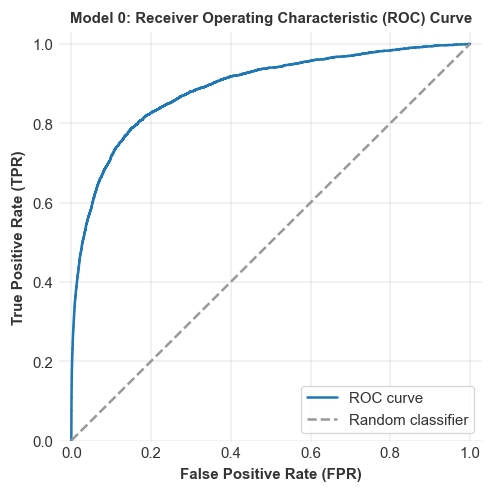

In [12]:
plot_utils.plot_roc_curve(
    p_valid_fpr,
    p_valid_tpr,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_roc_curve",
)

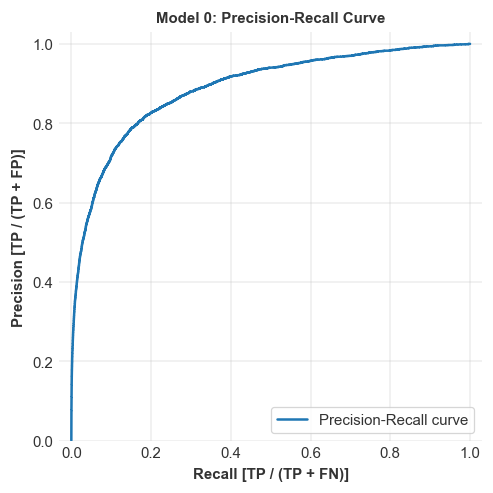

In [13]:
plot_utils.plot_precision_recall_curve(
    p_valid_fpr,
    p_valid_tpr,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_precision_recall_curve",
)

In [14]:

# -----------------------------
# Precision@K / Recall@K curves
# -----------------------------

def precision_recall_at_k(
    y_true: np.ndarray,
    y_score: np.ndarray,
    ks=(100, 500, 1000, 5000, 10000, 20000, 50000),
) -> pd.DataFrame:
    """
    Compute Precision@K and Recall@K for a binary classifier ranking.

    Parameters
    ----------
    y_true : array-like (n,)
        Binary labels {0,1}.
    y_score : array-like (n,)
        Model scores (higher = more likely positive).
    ks : iterable of int
        Cutoffs.

    Returns
    -------
    DataFrame with columns: K, tp, precision_at_k, recall_at_k.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)

    if y_true.ndim != 1 or y_score.ndim != 1 or y_true.shape[0] != y_score.shape[0]:
        raise ValueError("y_true and y_score must be 1D arrays of the same length.")

    n = y_true.shape[0]
    pos_total = int(y_true.sum())
    if pos_total == 0:
        raise ValueError("y_true contains no positives; recall is undefined.")

    # sort descending by score
    order = np.argsort(-y_score, kind="mergesort")  # stable for ties
    y_sorted = y_true[order]

    # cumulative true positives along the ranked list
    ctp = np.cumsum(y_sorted)

    rows = []
    for K in ks:
        k = int(min(max(K, 1), n))
        tp = int(ctp[k - 1])
        precision = tp / k
        recall = tp / pos_total
        rows.append((k, tp, precision, recall))

    return pd.DataFrame(rows, columns=["K", "tp", "precision_at_k", "recall_at_k"])


def plot_precision_recall_at_k(pr_df: pd.DataFrame, title_prefix: str = "Validation"):
    """
    Plot Precision@K and Recall@K vs K (log-scaled x-axis).
    """
    ks = pr_df["K"].to_numpy()
    prec = pr_df["precision_at_k"].to_numpy()
    rec = pr_df["recall_at_k"].to_numpy()

    plt.figure(figsize=(9, 5))
    plt.plot(ks, prec, marker="o")
    plt.xscale("log")
    plt.xlabel("K (top-K flagged; log scale)")
    plt.ylabel("Precision@K")
    plt.title(f"{title_prefix}: Precision@K")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(ks, rec, marker="o")
    plt.xscale("log")
    plt.xlabel("K (top-K flagged; log scale)")
    plt.ylabel("Recall@K")
    plt.title(f"{title_prefix}: Recall@K")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()



       K    tp  precision_at_k  recall_at_k
0    100    35         0.35000     0.009826
1    500   117         0.23400     0.032847
2   1000   178         0.17800     0.049972
3   5000   434         0.08680     0.121842
4  10000   627         0.06270     0.176025
5  20000   824         0.04120     0.231331
6  50000  1152         0.02304     0.323414


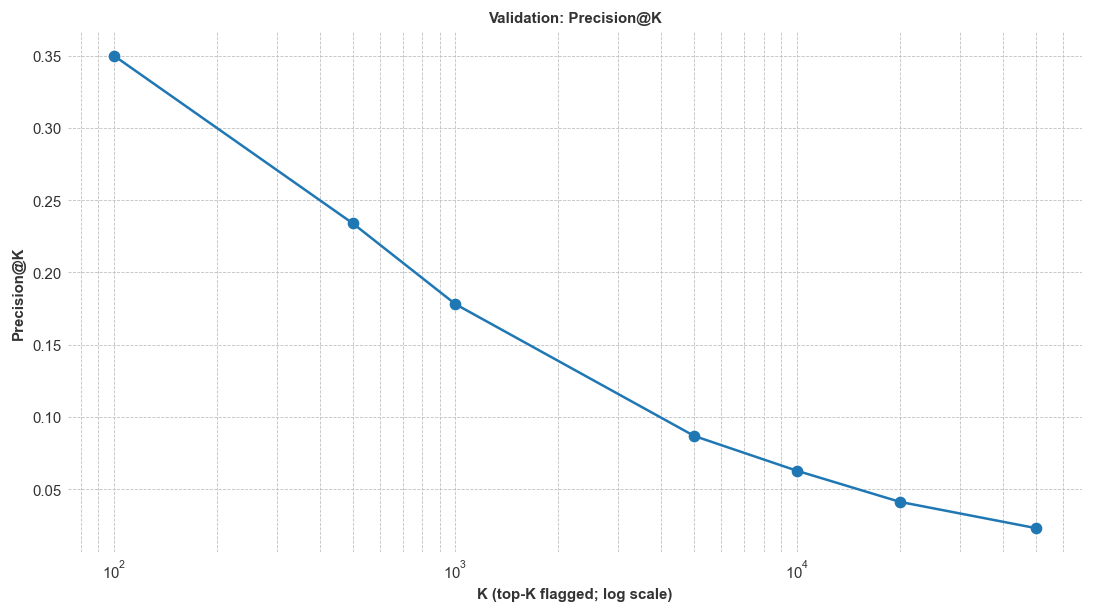

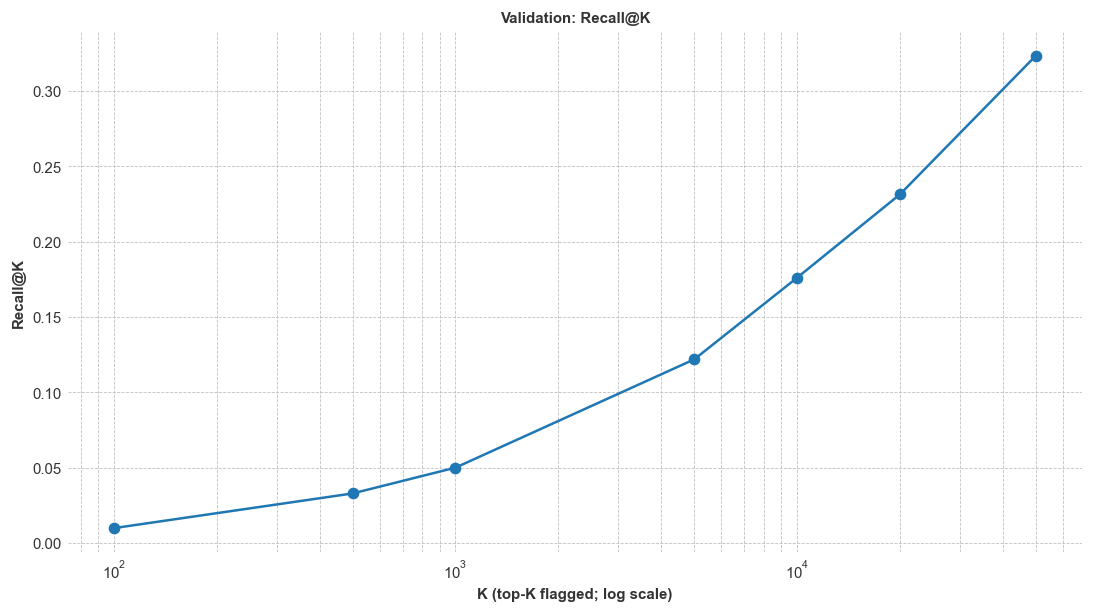

In [15]:
Ks = (100, 500, 1000, 5000, 10000, 20000, 50000)

pr_valid = precision_recall_at_k(y_valid.to_numpy(), p_valid, ks=Ks)
print(pr_valid)

plot_precision_recall_at_k(pr_valid, title_prefix="Validation")


#### Feature importance


In [16]:
importance_gain = gbm.feature_importance(importance_type="gain")

df_imp_gain = pd.DataFrame(
    {"feature": features, "importance_gain": importance_gain}
).sort_values("importance_gain", ascending=False)

df_imp_gain.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_feature_importance_gain.csv",
    index=False,
)
df_imp_gain

,feature,importance_gain
21,ab_nicu,631449.072001
46,mage_c,352722.249267
43,dbwt,143001.304189
35,ca_disor,131409.823761
27,ca_cchd,96975.473288
3,gestrec10,80469.592821
45,bmi,56698.241487
44,wtgain,54331.160841
19,ab_aven1,46335.062435
47,fagecomb,37094.820281


### Evaluation subset for permutation importances and SHAP analysis


In [17]:
X_eval, y_eval = ml_utils.build_explain_set(gbm, X_valid, y_valid, categorical)

In [18]:
model_wrapped = ml_utils.LGBMEstimator(gbm)

In [19]:
result = permutation_importance(
    model_wrapped,
    X_eval,
    y_eval,
    scoring=ml_utils.ap_scorer,
    n_repeats=20,
    n_jobs=8,
    random_state=RANDOM_SEED,
)

perm_importance = pd.DataFrame(
    {
        "feature": X_eval.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

perm_importance.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_permutation_importance.csv",
    index=False,
)
perm_importance

,feature,importance_mean,importance_std
46,mage_c,1.707151e-02,0.000635
35,ca_disor,1.641246e-02,0.000561
27,ca_cchd,1.535687e-02,0.000561
21,ab_nicu,1.057048e-02,0.000872
43,dbwt,3.943920e-03,0.000531
3,gestrec10,3.060263e-03,0.000665
16,dmeth_rec,1.549855e-03,0.000416
0,bfacil3,1.294022e-03,0.000198
20,ab_aven6,1.057359e-03,0.000190
36,meduc,9.563218e-04,0.000285


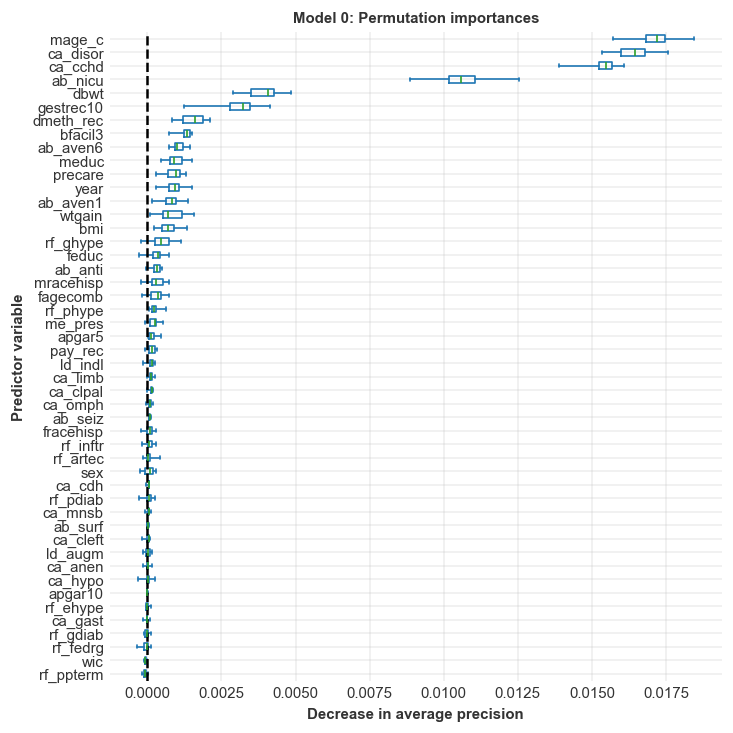

In [20]:
plot_utils.plot_permutation_importances(
    result,
    X_eval,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_permutation_importances",
)

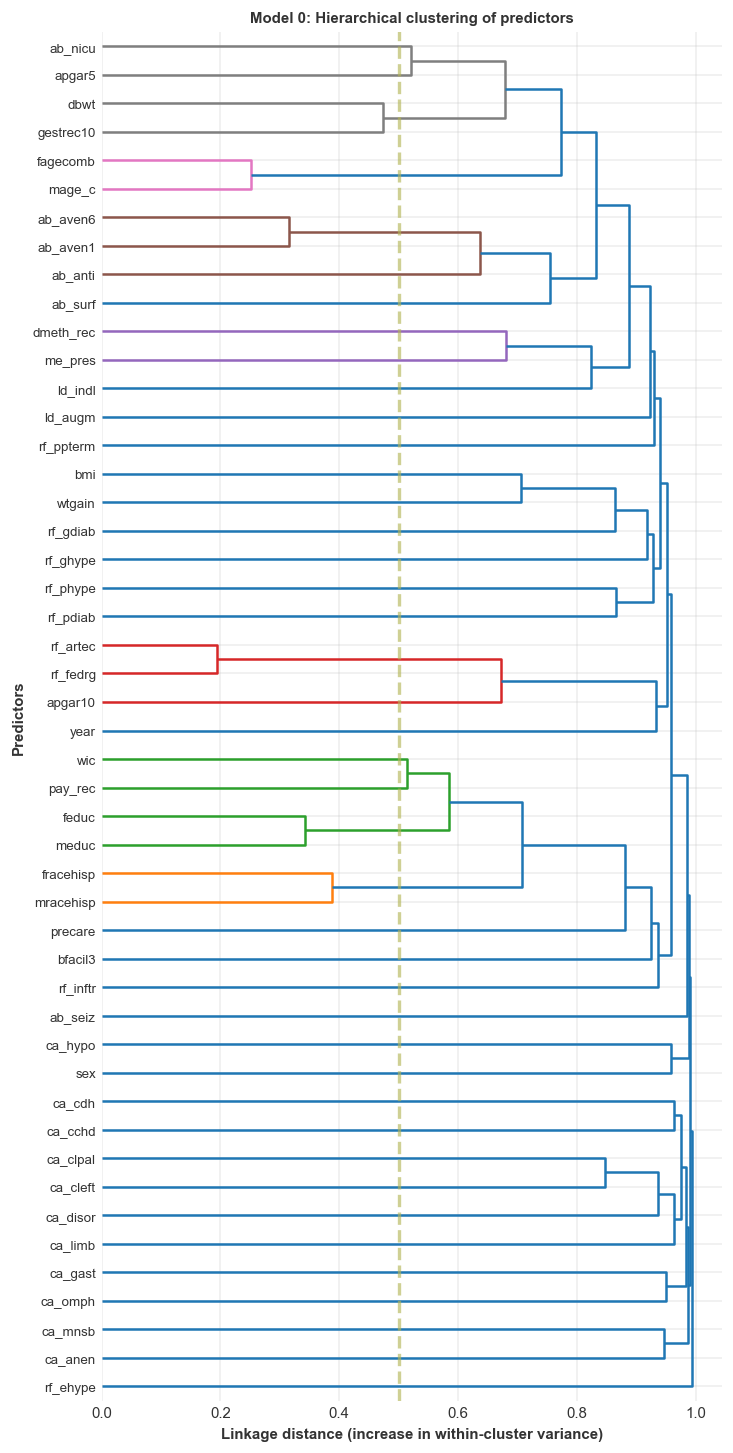

In [21]:
distance, corr = stats_utils.distance_corr_dissimilarity(X_eval)
condensed = squareform(distance, checks=True)
dist_linkage = hierarchy.linkage(condensed, method="average")
dendro_labels = X_eval.columns.to_list()
dendro = plot_utils.plot_dendrogram(
    dist_linkage,
    dendro_labels,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_dendrogram",
)

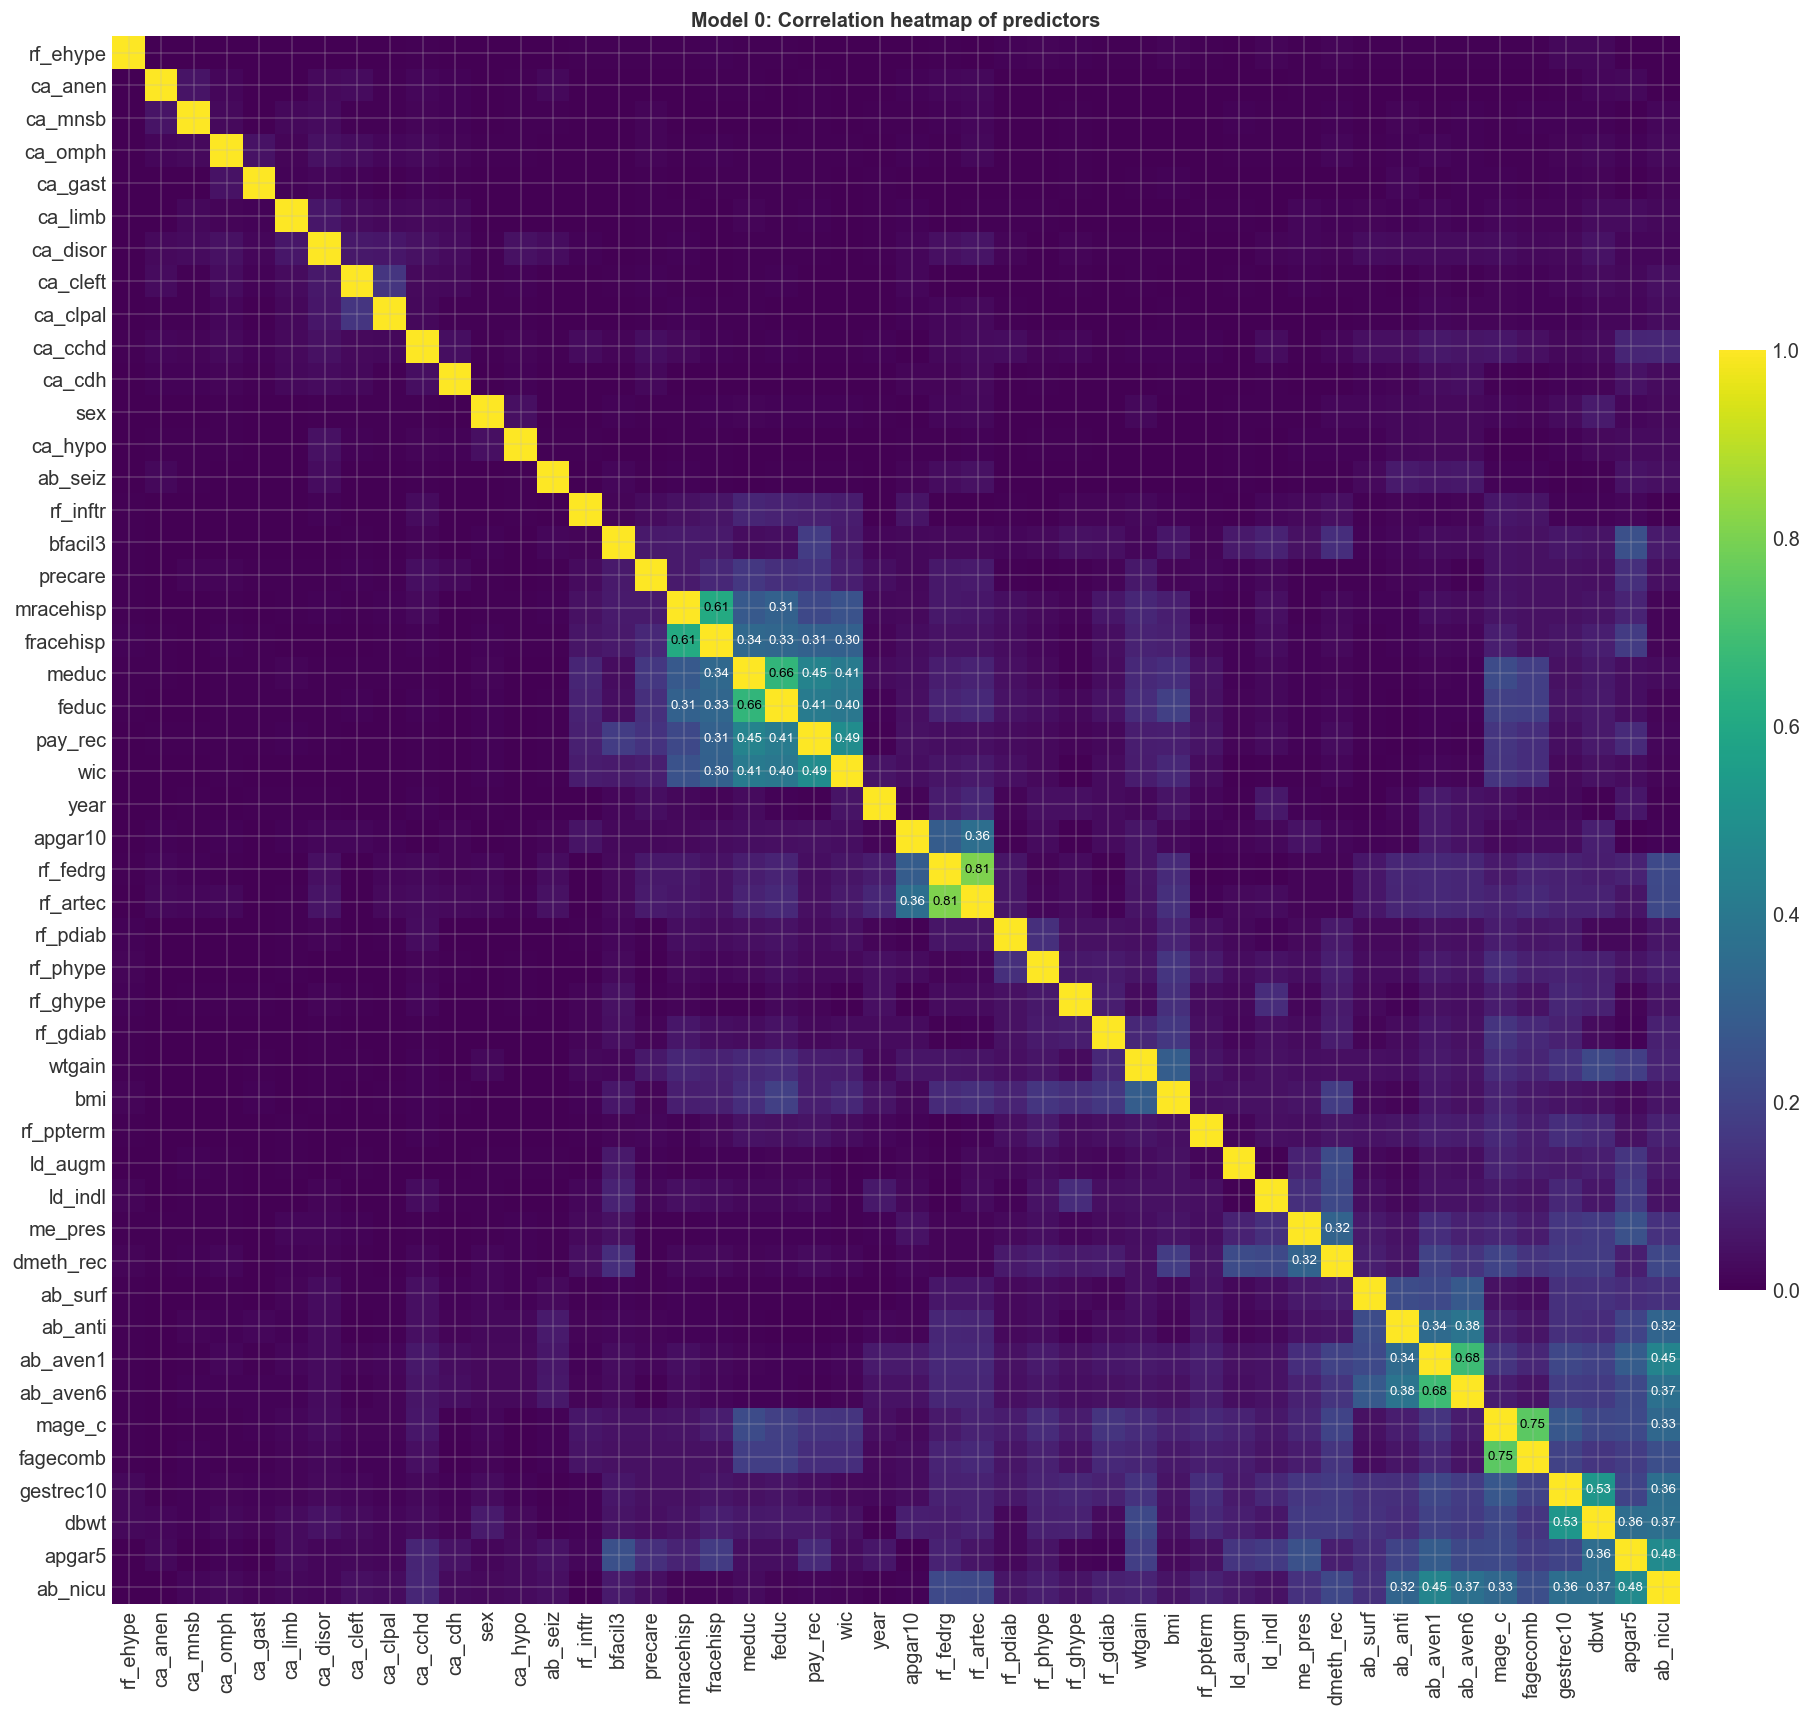

In [22]:
plot_utils.plot_correlation_heatmap(
    corr,
    dendro,
    label_threshold=0.3,
    model_idx=model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_correlation_heatmap",
)

In [23]:
explainer = shap.TreeExplainer(
    gbm, feature_perturbation="tree_path_dependent", model_output="raw"
)

explanation = explainer(X_eval)

clustering = shap.utils.hclust(
    X_eval, y_eval, linkage="average", random_state=RANDOM_SEED
)

shap_values = explanation.values

shap_importance = pd.DataFrame(
    {
        "feature": X_eval.columns,
        "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_shap_importance.csv",
    index=False,
)
shap_importance

c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\shap\utils\_clustering.py:170: UserWarning: No/low signal found from feature 0 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\shap\utils\_clustering.py:170: UserWarning: No/low signal found from feature 1 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\shap\utils\_clustering.py:170: UserWarning: No/low signal found from feature 2 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
c:\Users\FrankBuckley\

,feature,mean_abs_shap
21,ab_nicu,0.942227
46,mage_c,0.744345
43,dbwt,0.380824
3,gestrec10,0.316718
19,ab_aven1,0.203361
37,mracehisp,0.136769
44,wtgain,0.091460
42,year,0.077876
27,ca_cchd,0.067745
16,dmeth_rec,0.063944


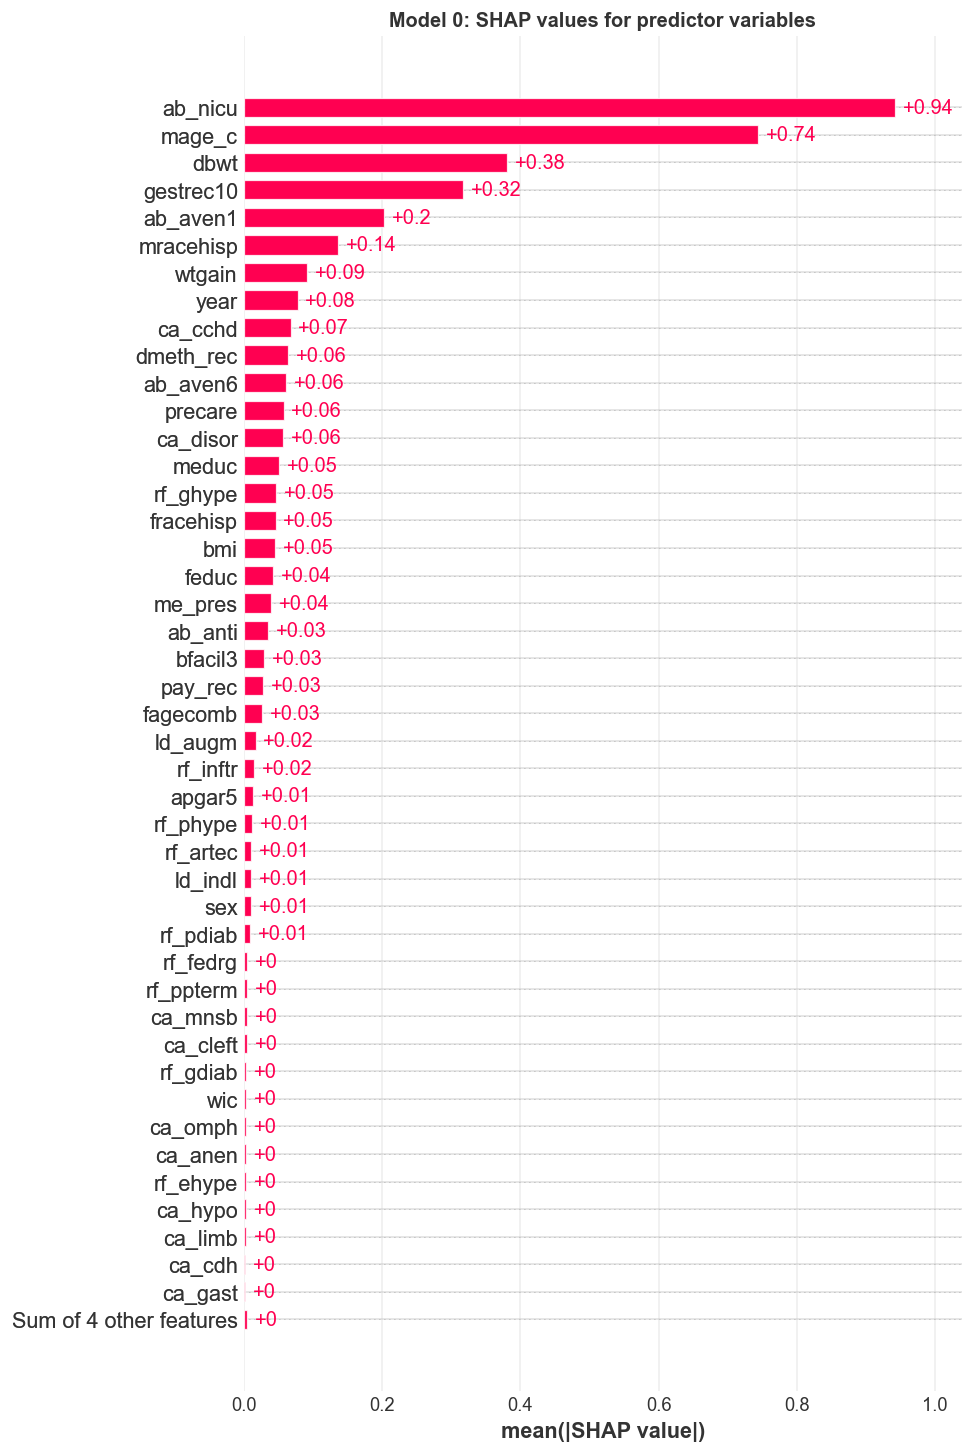

<Figure size 492x348 with 0 Axes>

In [24]:
with plt.rc_context({"axes.titlesize": 12}):
    plot = plt.figure(figsize=(8, 12))
    ax = plot.subplots()
    ax.set_title(f"Model {model_idx}: SHAP values for predictor variables")
    shap.plots.bar(explanation, max_display=45, ax=ax)
    if SAVE_PLOTS:
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_bar.png", dpi=300, bbox_inches="tight"
        )
        plt.savefig(f"{OUTPUT_DIR}/model_{model_idx}_shap_bar.svg", bbox_inches="tight")
    plt.show()

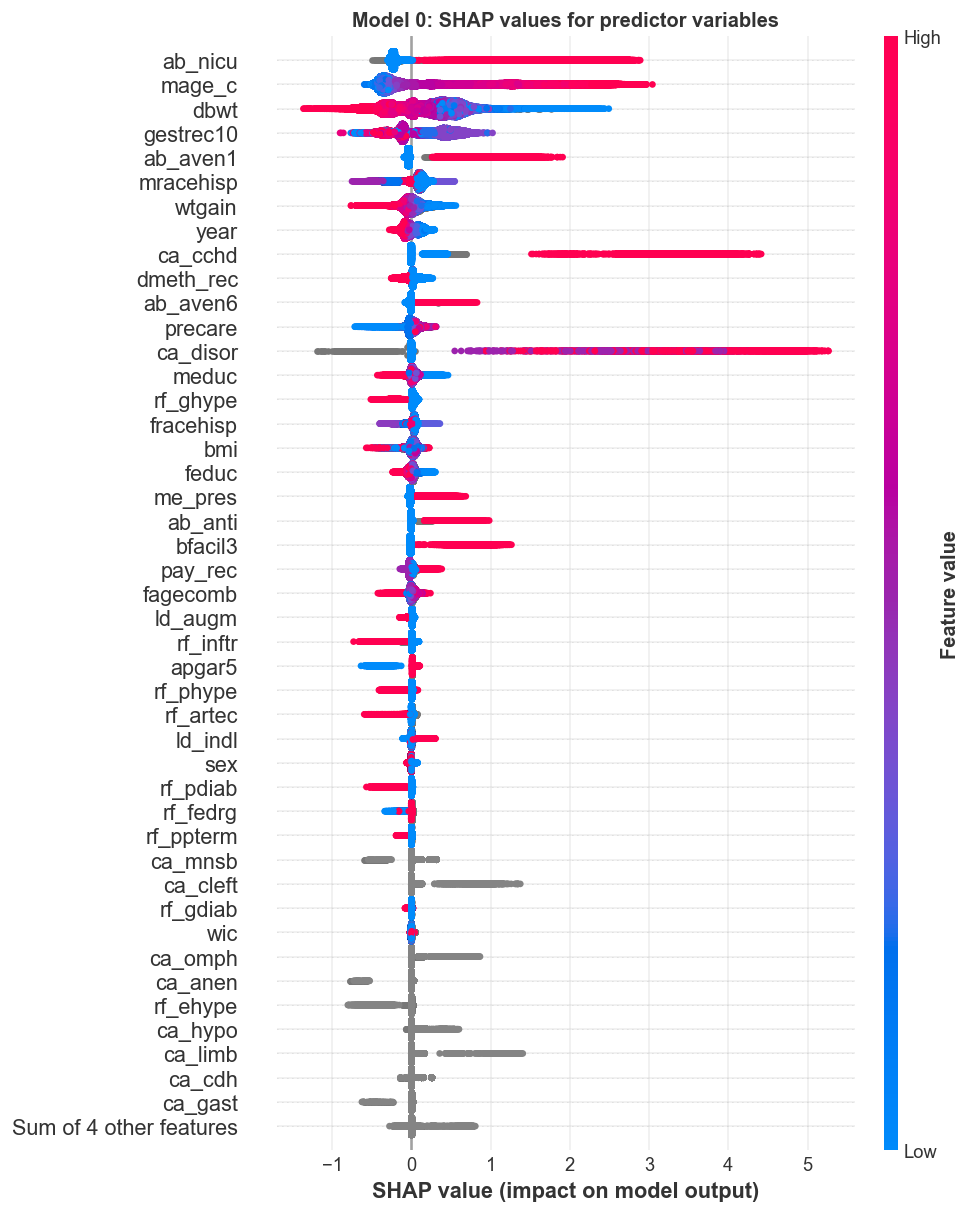

<Figure size 492x348 with 0 Axes>

In [25]:
with plt.rc_context({"axes.titlesize": 12}):
    plot = plt.figure()
    ax = plot.subplots()
    ax.set_title(f"Model {model_idx}: SHAP values for predictor variables")
    shap.plots.beeswarm(explanation, max_display=45, plot_size=(8, 10))
    if SAVE_PLOTS:
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_beeswarm.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_beeswarm.svg",
            bbox_inches="tight",
        )
    plt.show()

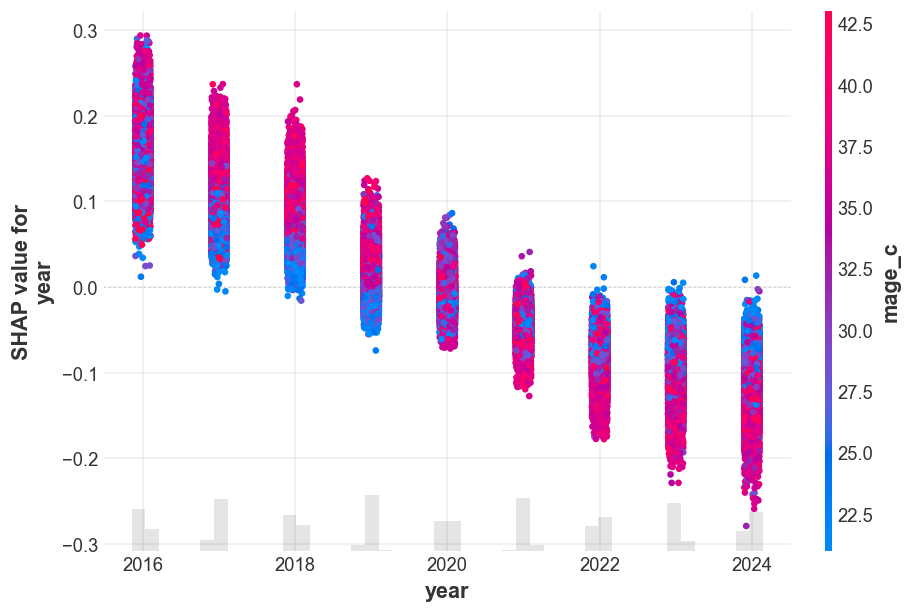

<Figure size 492x348 with 0 Axes>

In [26]:
ax = shap.plots.scatter(explanation[:, "year"], color=explanation[:, "mage_c"])
# ax.set_title(f"Model {model_idx}: SHAP values for year vs maternal age")
if SAVE_PLOTS:
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_maternal_age.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_maternal_age.svg",
        bbox_inches="tight",
    )
plt.show()

## Model 1


In [27]:
features_to_remove_0 = [
    "ca_cdh",
    "apgar10",
    "ca_cleft",
    "rf_artec",
    "ca_omph",
    "ca_clpal",
    "wic",
    "ca_limb",
    "rf_pdiab",
    "ca_hypo",
    "rf_ppterm",
    "ca_mnsb",
    "rf_ehype",
    "ca_anen",
    "ca_gast",
    "ab_surf",
    "rf_gdiab",
    "ab_seiz",
]

X_train = X_train.drop(columns=features_to_remove_0)
X_valid = X_valid.drop(columns=features_to_remove_0)

features = X_train.columns.to_list()
categorical = [col for col in categorical if col not in features_to_remove_0]

train_data = lgb.Dataset(
    X_train, label=y_train, categorical_feature=categorical, free_raw_data=False
)

valid_data = lgb.Dataset(
    X_valid,
    label=y_valid,
    categorical_feature=categorical,
    reference=train_data,
    free_raw_data=False,
)

model_idx = 1
model_name = (
    f"Model {model_idx} (after removing {len(features_to_remove_0)} predictors)"
)

print(f"Features removed: {features_to_remove_0}")
print(f"Features remaining: {features}")
print(f"Number of features in {model_name}: {X_train.shape[1]}")

Features removed: ['ca_cdh', 'apgar10', 'ca_cleft', 'rf_artec', 'ca_omph', 'ca_clpal', 'wic', 'ca_limb', 'rf_pdiab', 'ca_hypo', 'rf_ppterm', 'ca_mnsb', 'rf_ehype', 'ca_anen', 'ca_gast', 'ab_surf', 'rf_gdiab', 'ab_seiz']
Features remaining: ['bfacil3', 'sex', 'precare', 'gestrec10', 'rf_phype', 'rf_ghype', 'rf_inftr', 'rf_fedrg', 'ld_indl', 'ld_augm', 'me_pres', 'dmeth_rec', 'apgar5', 'ab_aven1', 'ab_aven6', 'ab_nicu', 'ab_anti', 'ca_cchd', 'ca_disor', 'meduc', 'mracehisp', 'feduc', 'fracehisp', 'pay_rec', 'year', 'dbwt', 'wtgain', 'bmi', 'mage_c', 'fagecomb']
Number of features in Model 1 (after removing 18 predictors): 30


In [28]:
gbm = lgb.train(
    params,
    train_data,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[
        early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
        log_evaluation(period=10),
    ],
)

best_iter = gbm.best_iteration
gbm.save_model(
    f"{OUTPUT_DIR}/model_{model_idx}.txt",
    num_iteration=best_iter,
)

[LightGBM] [Info] Number of positive: 14247, number of negative: 26857135
[LightGBM] [Info] Total Bins 841
[LightGBM] [Info] Number of data points in the train set: 26871382, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000530 -> initscore=-7.541740
[LightGBM] [Info] Start training from score -7.541740
Training until validation scores don't improve for 200 rounds
[10]	train's average_precision: 0.0245859	train's binary_logloss: 0.00416344	valid's average_precision: 0.0251922	valid's binary_logloss: 0.00417028
[20]	train's average_precision: 0.0274922	train's binary_logloss: 0.00401205	valid's average_precision: 0.0282223	valid's binary_logloss: 0.004025
[30]	train's average_precision: 0.0292071	train's binary_logloss: 0.00390679	valid's average_precision: 0.0291509	valid's binary_logloss: 0.00392597
[40]	train's average_precision: 0.0304435	train's binary_logloss: 0.0038338	valid's average_precision: 0.029418	valid's binary_logloss: 0.00385842
[50]	trai

In [29]:
p_valid = gbm.predict(X_valid, num_iteration=best_iter)

In [30]:
metrics_df, p_valid_fpr, p_valid_tpr, p_valid_thresholds, tp, fp, n_pos = ml_utils.get_metrics(
    y_valid, p_valid, K=10000, thr=0.01
)

metrics_df.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_validation_metrics.csv",
    index=False,
)

metrics_df

,metric,value
0,Validation AUC,0.888724
1,Validation AP,0.036112
2,Validation log loss,0.003593
3,Precision at 10000,0.062100
4,Recall at 10000,0.174340
5,Precision (threshold=0.01),0.027421
6,Recall (threshold=0.01),0.288321


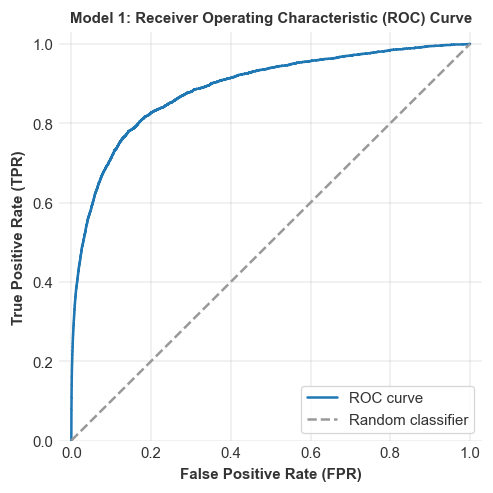

In [31]:
plot_utils.plot_roc_curve(
    p_valid_fpr,
    p_valid_tpr,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_roc_curve",
)

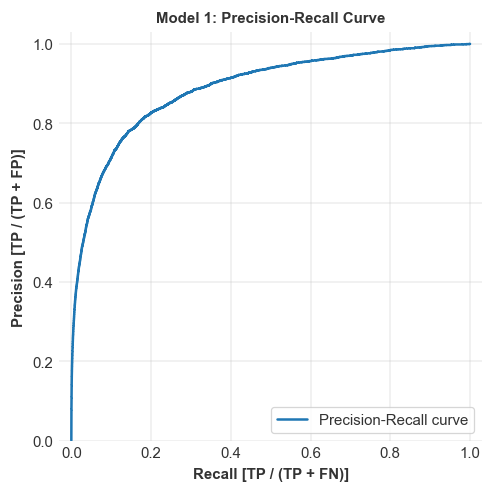

In [32]:
plot_utils.plot_precision_recall_curve(
    p_valid_fpr,
    p_valid_tpr,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_precision_recall_curve",
)

In [33]:
importance_gain = gbm.feature_importance(importance_type="gain")

df_imp_gain = pd.DataFrame(
    {"feature": features, "importance_gain": importance_gain}
).sort_values("importance_gain", ascending=False)

df_imp_gain.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_feature_importance_gain.csv",
    index=False,
)
df_imp_gain

,feature,importance_gain
15,ab_nicu,628370.084318
28,mage_c,334585.703377
25,dbwt,144532.212907
18,ca_disor,133770.445055
17,ca_cchd,119488.058543
3,gestrec10,79827.443403
13,ab_aven1,62215.550713
27,bmi,56225.113642
26,wtgain,53170.277588
29,fagecomb,41662.564453


In [34]:
X_eval, y_eval = ml_utils.build_explain_set(gbm, X_valid, y_valid, categorical)

model_wrapped = ml_utils.LGBMEstimator(gbm)

In [35]:
result = permutation_importance(
    model_wrapped,
    X_eval,
    y_eval,
    scoring=ml_utils.ap_scorer,
    n_repeats=20,
    n_jobs=8,
    random_state=RANDOM_SEED,
)

perm_importance = pd.DataFrame(
    {
        "feature": X_eval.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

perm_importance.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_permutation_importance.csv",
    index=False,
)
perm_importance

,feature,importance_mean,importance_std
28,mage_c,0.016239,0.000676
18,ca_disor,0.015762,0.000444
17,ca_cchd,0.015323,0.000488
15,ab_nicu,0.008834,0.000795
25,dbwt,0.003883,0.000492
3,gestrec10,0.003008,0.000620
11,dmeth_rec,0.001570,0.000385
13,ab_aven1,0.001209,0.000287
0,bfacil3,0.001188,0.000370
2,precare,0.001106,0.000231


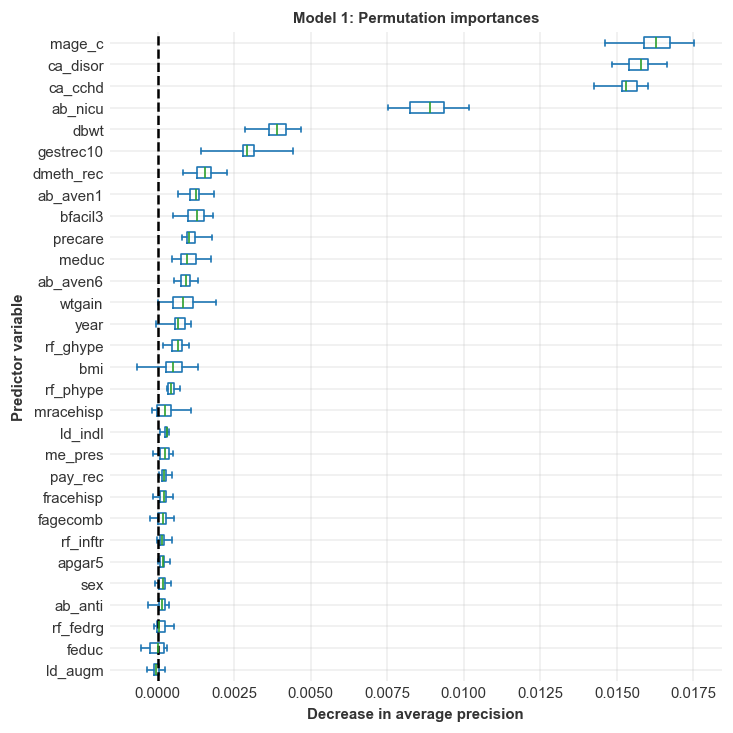

In [36]:
plot_utils.plot_permutation_importances(
    result,
    X_eval,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_permutation_importances",
)

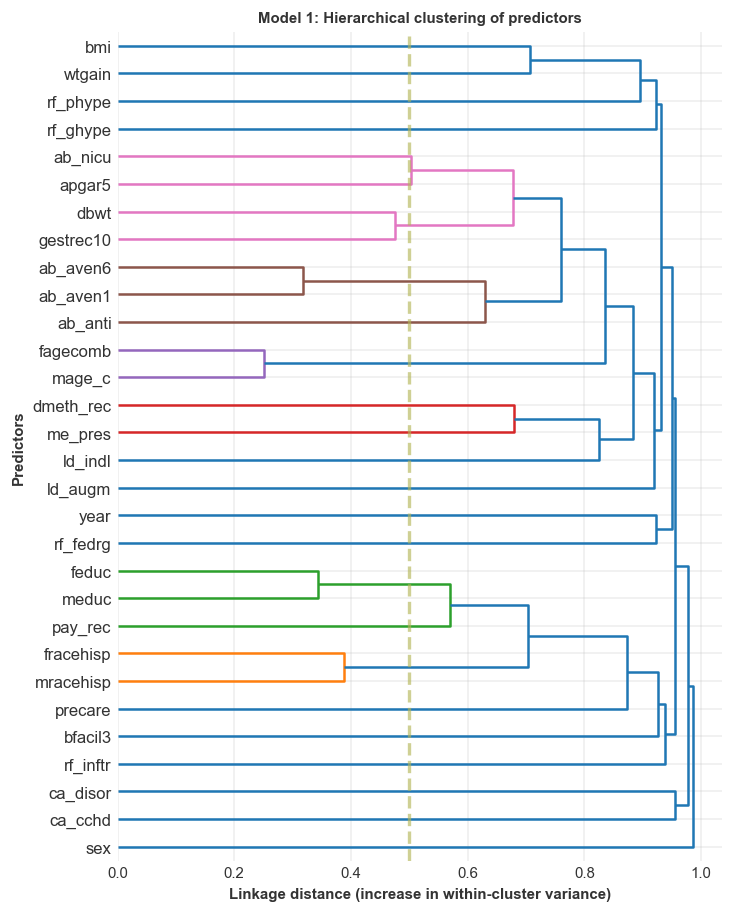

In [37]:
distance, corr = stats_utils.distance_corr_dissimilarity(X_eval)
condensed = squareform(distance, checks=True)
dist_linkage = hierarchy.linkage(condensed, method="average")
dendro_labels = X_eval.columns.to_list()
dendro = plot_utils.plot_dendrogram(
    dist_linkage,
    dendro_labels,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_dendrogram",
)

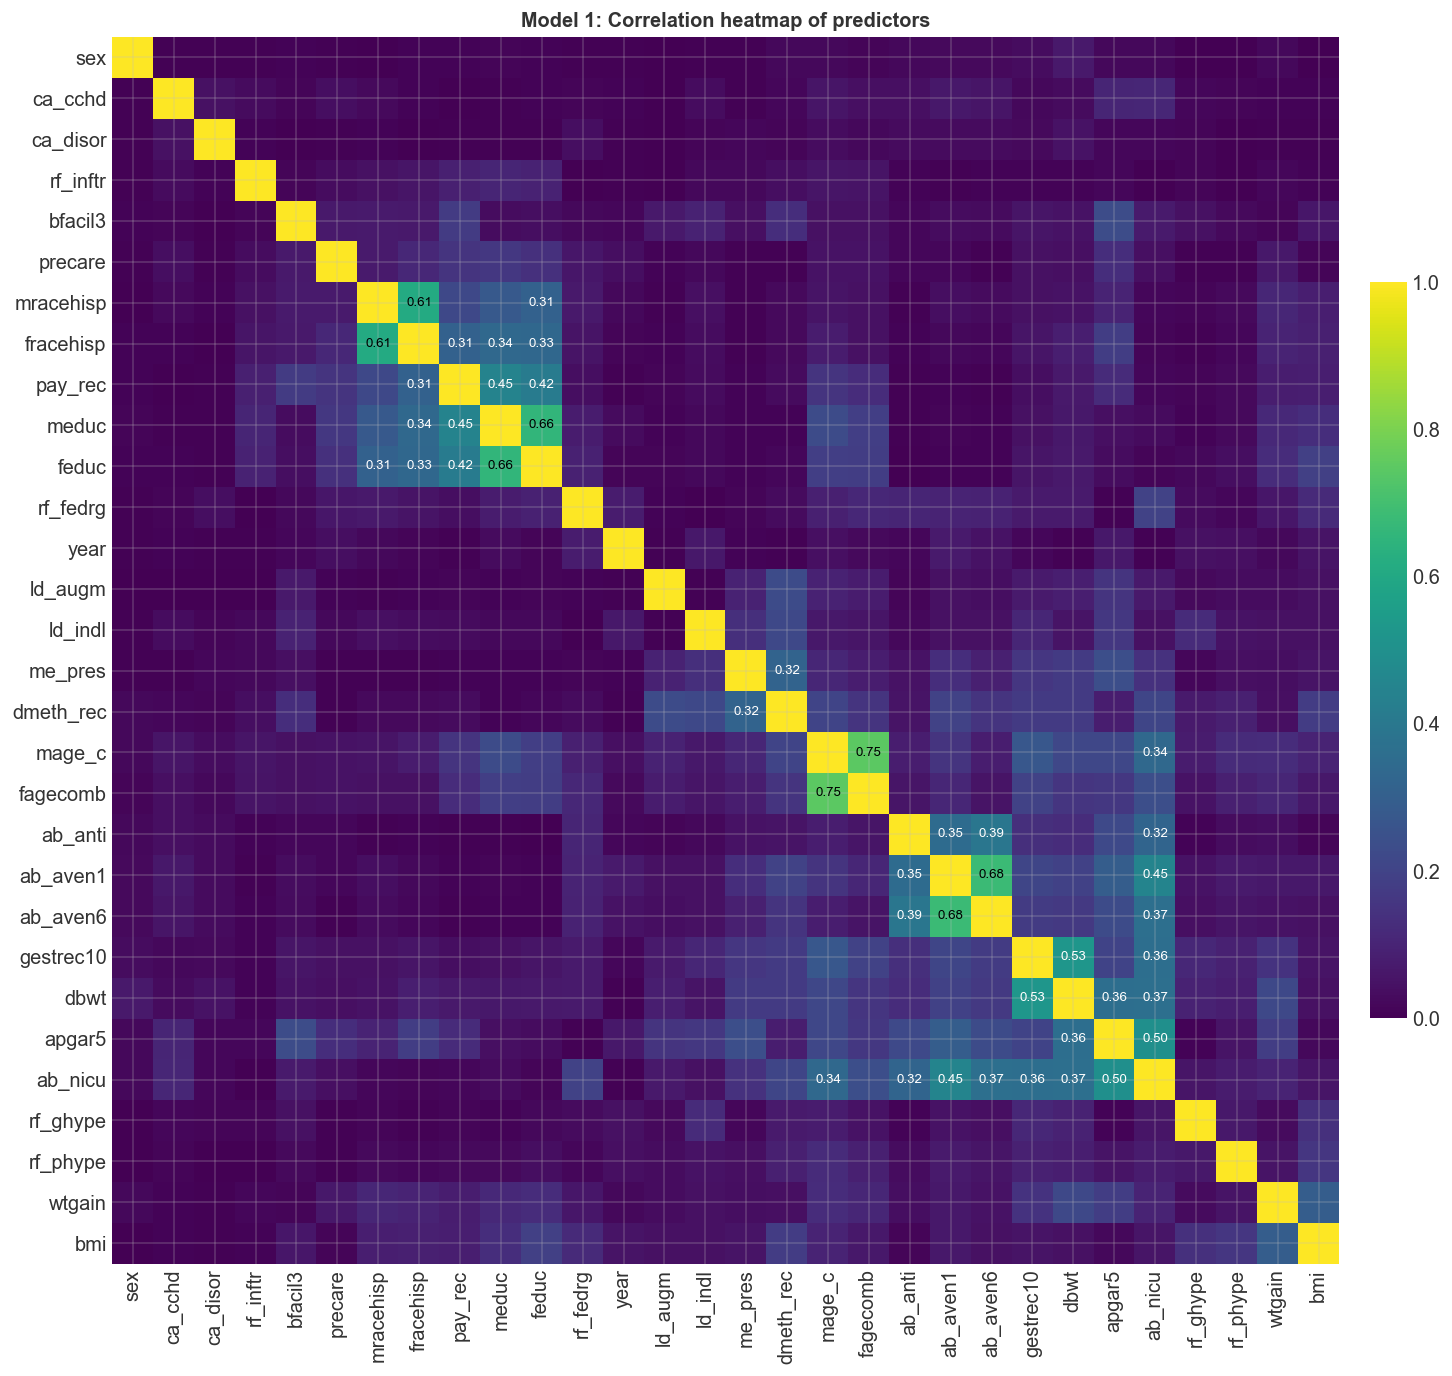

In [38]:
plot_utils.plot_correlation_heatmap(
    corr,
    dendro,
    label_threshold=0.3,
    model_idx=model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_correlation_heatmap",
)

In [39]:
explainer = shap.TreeExplainer(
    gbm, feature_perturbation="tree_path_dependent", model_output="raw"
)

explanation = explainer(X_eval)

clustering = shap.utils.hclust(
    X_eval, y_eval, linkage="average", random_state=RANDOM_SEED
)

shap_values = explanation.values

shap_importance = pd.DataFrame(
    {
        "feature": X_eval.columns,
        "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_shap_importance.csv",
    index=False,
)
shap_importance

c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\shap\utils\_clustering.py:170: UserWarning: No/low signal found from feature 0 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\shap\utils\_clustering.py:170: UserWarning: No/low signal found from feature 1 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
c:\Users\FrankBuckley\miniconda3\envs\data-stats-models-ml\Lib\site-packages\shap\utils\_clustering.py:170: UserWarning: No/low signal found from feature 2 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all redundancy distances to 1).
  warnings.warn(
c:\Users\FrankBuckley\

,feature,mean_abs_shap
15,ab_nicu,0.941965
28,mage_c,0.742175
25,dbwt,0.384039
3,gestrec10,0.314304
13,ab_aven1,0.208163
20,mracehisp,0.136552
26,wtgain,0.090314
24,year,0.078290
17,ca_cchd,0.074171
11,dmeth_rec,0.066429


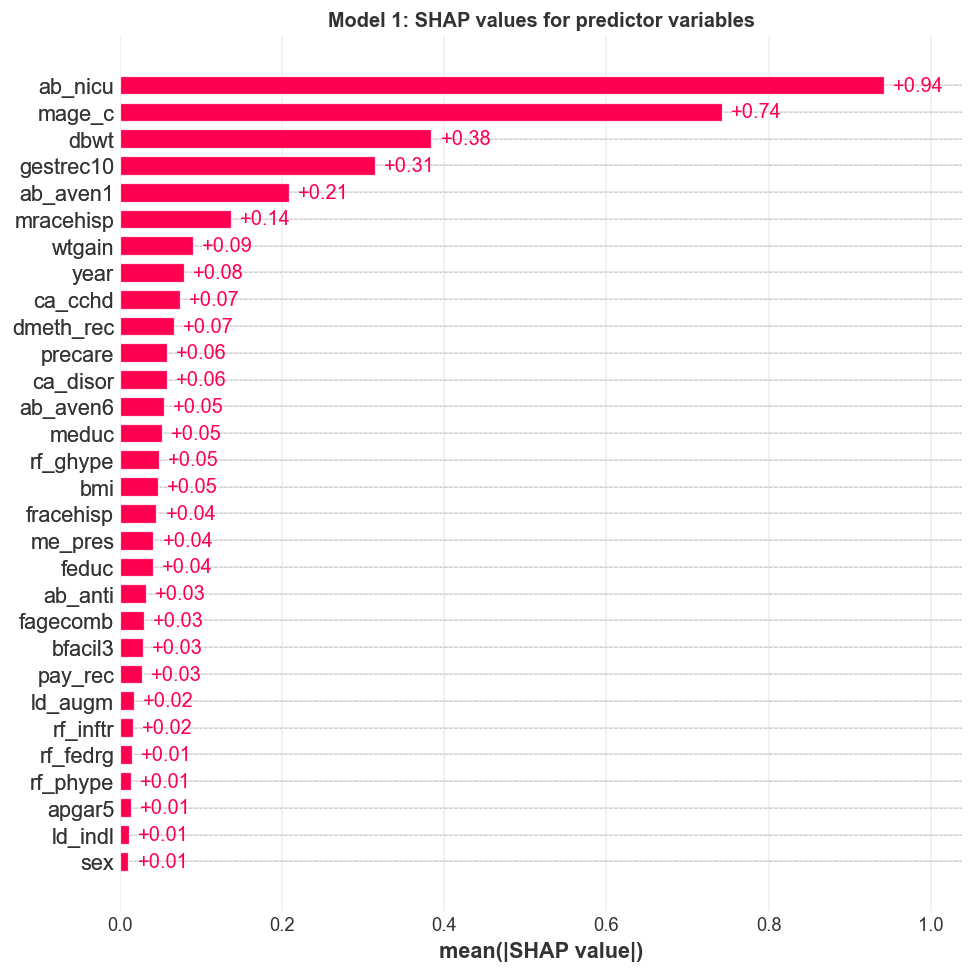

<Figure size 492x348 with 0 Axes>

In [40]:
with plt.rc_context({"axes.titlesize": 12}):
    plot = plt.figure(figsize=(8, 8))
    ax = plot.subplots()
    ax.set_title(f"Model {model_idx}: SHAP values for predictor variables")
    shap.plots.bar(explanation, max_display=35, ax=ax)
    if SAVE_PLOTS:
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_bar.png", dpi=300, bbox_inches="tight"
        )
        plt.savefig(f"{OUTPUT_DIR}/model_{model_idx}_shap_bar.svg", bbox_inches="tight")
    plt.show()

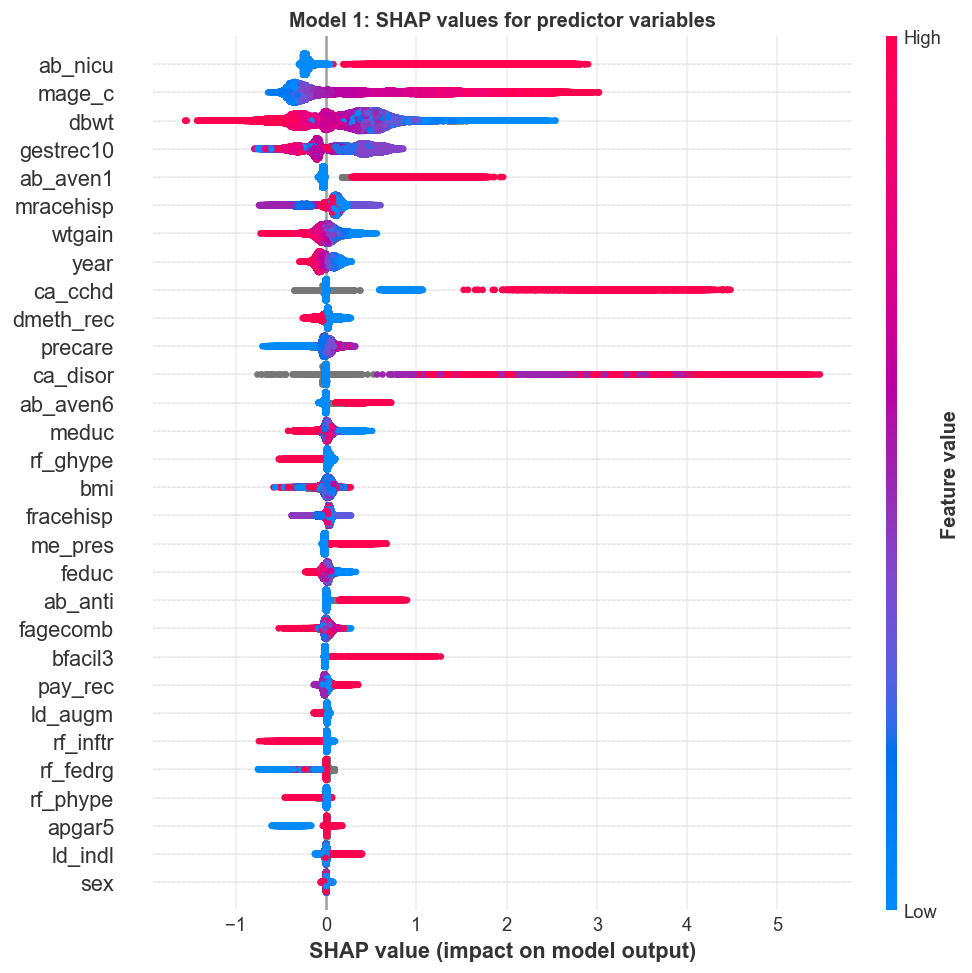

<Figure size 492x348 with 0 Axes>

In [41]:
with plt.rc_context({"axes.titlesize": 12}):
    plot = plt.figure()
    ax = plot.subplots()
    ax.set_title(f"Model {model_idx}: SHAP values for predictor variables")
    shap.plots.beeswarm(explanation, max_display=40, plot_size=(8, 8))
    if SAVE_PLOTS:
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_beeswarm.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_beeswarm.svg",
            bbox_inches="tight",
        )
    plt.show()

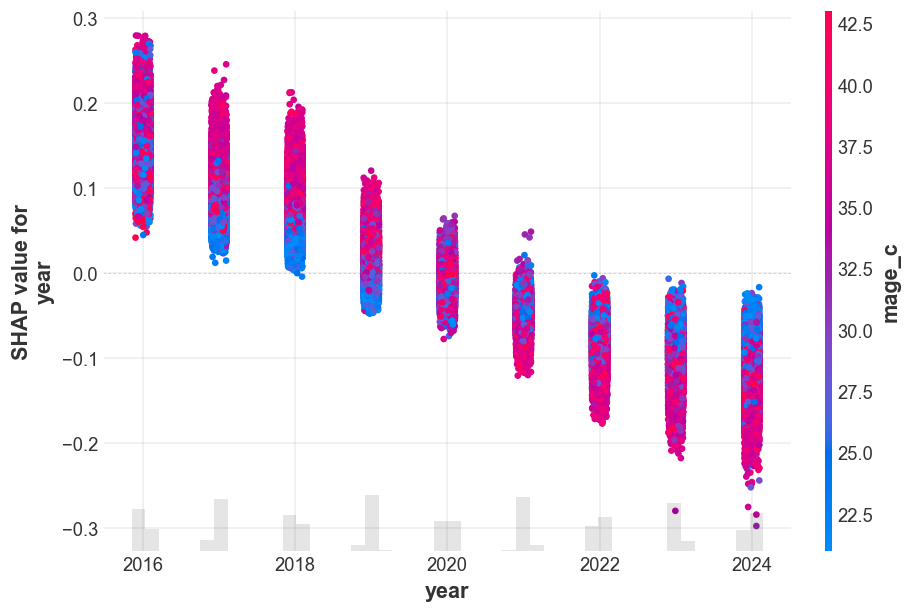

<Figure size 492x348 with 0 Axes>

In [42]:
shap.plots.scatter(explanation[:, "year"], color=explanation[:, "mage_c"])
#plt.title(f"Model {model_idx}: SHAP values for year vs maternal age")
if SAVE_PLOTS:
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_maternal_age.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_maternal_age.svg",
        bbox_inches="tight",
    )
plt.show()

## Model 2


In [ ]:
features_to_remove_1 = [
]

X_train = X_train.drop(columns=features_to_remove_1)
X_valid = X_valid.drop(columns=features_to_remove_1)

features = X_train.columns.to_list()
categorical = [col for col in categorical if col not in features_to_remove_1]

train_data = lgb.Dataset(
    X_train, label=y_train, categorical_feature=categorical, free_raw_data=False
)

valid_data = lgb.Dataset(
    X_valid,
    label=y_valid,
    categorical_feature=categorical,
    reference=train_data,
    free_raw_data=False,
)

model_idx = 2
model_name = (
    f"Model {model_idx} (after removing {len(features_to_remove_1)} predictors)"
)

print(f"Features removed: {features_to_remove_1}")
print(f"Features remaining: {features}")
print(f"Number of features in {model_name}: {X_train.shape[1]}")

In [ ]:
gbm = lgb.train(
    params,
    train_data,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[
        early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
        log_evaluation(period=10),
    ],
)

best_iter = gbm.best_iteration
gbm.save_model(
    f"{OUTPUT_DIR}/model_{model_idx}.txt",
    num_iteration=best_iter,
)

In [ ]:
p_valid = gbm.predict(X_valid, num_iteration=best_iter)

In [ ]:
metrics_df, p_valid_fpr, p_valid_tpr, p_valid_thresholds, tp, fp, n_pos = ml_utils.get_metrics(
    y_valid, p_valid, K=10000, thr=0.01
)

metrics_df.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_validation_metrics.csv",
    index=False,
)

metrics_df

In [ ]:
plot_utils.plot_roc_curve(
    p_valid_fpr,
    p_valid_tpr,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_roc_curve",
)

In [ ]:
plot_utils.plot_precision_recall_curve(
    p_valid_fpr,
    p_valid_tpr,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_precision_recall_curve",
)

In [ ]:

pr_valid = precision_recall_at_k(y_valid.to_numpy(), p_valid, ks=Ks)
print(pr_valid)

plot_precision_recall_at_k(pr_valid, title_prefix="Validation")


In [ ]:
importance_gain = gbm.feature_importance(importance_type="gain")

df_imp_gain = pd.DataFrame(
    {"feature": features, "importance_gain": importance_gain}
).sort_values("importance_gain", ascending=False)

df_imp_gain.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_feature_importance_gain.csv",
    index=False,
)
df_imp_gain

In [ ]:
X_eval, y_eval = ml_utils.build_explain_set(gbm, X_valid, y_valid, categorical)

model_wrapped = ml_utils.LGBMEstimator(gbm)

In [ ]:
result = permutation_importance(
    model_wrapped,
    X_eval,
    y_eval,
    scoring=ml_utils.ap_scorer,
    n_repeats=20,
    n_jobs=8,
    random_state=RANDOM_SEED,
)

perm_importance = pd.DataFrame(
    {
        "feature": X_eval.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

perm_importance.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_permutation_importance.csv",
    index=False,
)
perm_importance

In [ ]:
plot_utils.plot_permutation_importances(
    result,
    X_eval,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_permutation_importances",
)

In [ ]:
distance, corr = stats_utils.distance_corr_dissimilarity(X_eval)
condensed = squareform(distance, checks=True)
dist_linkage = hierarchy.linkage(condensed, method="average")
dendro_labels = X_eval.columns.to_list()
dendro = plot_utils.plot_dendrogram(
    dist_linkage,
    dendro_labels,
    model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_dendrogram",
)

In [ ]:
plot_utils.plot_correlation_heatmap(
    corr,
    dendro,
    label_threshold=0.3,
    model_idx=model_idx,
    save=SAVE_PLOTS,
    output_dir=OUTPUT_DIR,
    file_name=f"model_{model_idx}_correlation_heatmap",
)

In [ ]:
explainer = shap.TreeExplainer(
    gbm, feature_perturbation="tree_path_dependent", model_output="raw"
)

explanation = explainer(X_eval)

clustering = shap.utils.hclust(
    X_eval, y_eval, linkage="average", random_state=RANDOM_SEED
)

shap_values = explanation.values

shap_importance = pd.DataFrame(
    {
        "feature": X_eval.columns,
        "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_shap_importance.csv",
    index=False,
)
shap_importance

In [ ]:
with plt.rc_context({"axes.titlesize": 12}):
    plot = plt.figure(figsize=(8, 8))
    ax = plot.subplots()
    ax.set_title(f"Model {model_idx}: SHAP values for predictor variables")
    shap.plots.bar(explanation, max_display=35, ax=ax)
    if SAVE_PLOTS:
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_bar.png", dpi=300, bbox_inches="tight"
        )
        plt.savefig(f"{OUTPUT_DIR}/model_{model_idx}_shap_bar.svg", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context({"axes.titlesize": 12}):
    plot = plt.figure()
    ax = plot.subplots()
    ax.set_title(f"Model {model_idx}: SHAP values for predictor variables")
    shap.plots.beeswarm(explanation, max_display=30, plot_size=(8, 7))
    if SAVE_PLOTS:
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_beeswarm.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.savefig(
            f"{OUTPUT_DIR}/model_{model_idx}_shap_beeswarm.svg",
            bbox_inches="tight",
        )
    plt.show()

In [ ]:
ax = shap.plots.scatter(explanation[:, "year"], color=explanation[:, "mage_c"])
if SAVE_PLOTS:
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_maternal_age.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_maternal_age.svg",
        bbox_inches="tight",
    )
plt.show()

In [ ]:
ax = shap.plots.scatter(explanation[:, "year"], color=explanation[:, "fagecomb"])
if SAVE_PLOTS:
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_paternal_age.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_year_vs_paternal_age.svg",
        bbox_inches="tight",
    )
plt.show()

In [ ]:
ax = shap.plots.scatter(explanation[:, "mage_c"], color=explanation[:, "fagecomb"])
if SAVE_PLOTS:
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_maternal_age_vs_paternal_age.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"{OUTPUT_DIR}/model_{model_idx}_shap_maternal_age_vs_paternal_age.svg",
        bbox_inches="tight",
    )
plt.show()

In [ ]:
ax = shap.plots.scatter(explanation[:, "bmi"], color=explanation[:, "mage_c"])
plt.show()

In [ ]:
ax = shap.plots.scatter(explanation[:, "ab_nicu"], color=explanation[:, "ab_aven1"])
plt.show()

In [ ]:
ax = shap.plots.scatter(explanation[:, "ca_cchd"], color=explanation[:, "ab_nicu"])
plt.show()

## Prediction


In [ ]:
p_valid = gbm.predict(X_valid, num_iteration=gbm.best_iteration, raw_score=False)

print("best_iteration:", gbm.best_iteration)
print("mean raw prob:", float(p_valid.mean()))


print("Raw logloss:", log_loss(y_valid, p_valid, labels=[0, 1]))
print("Raw brier:  ", brier_score_loss(y_valid, p_valid))

In [ ]:
def tail_calibration_table(y, p, fracs=(1e-2, 1e-3, 1e-4, 1e-5)):
    """
    Compare predicted vs observed event rates in the top fracs of scores.

    Parameters
    ----------
    y : array-like (0/1)
    p : array-like (probabilities)
    fracs : iterable of floats
        Fractions like 1e-3 for top 0.1%.

    Returns
    -------
    DataFrame with k, predicted mean, observed rate, and counts.
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    y_sorted = y[order]
    p_sorted = p[order]

    N = len(y)
    rows = []
    for f in fracs:
        k = max(1, int(round(N * f)))
        y_top = y_sorted[:k]
        p_top = p_sorted[:k]

        obs_rate = y_top.mean()
        pred_rate = p_top.mean()

        tp = int(y_top.sum())
        fp = int(k - tp)

        rows.append(
            {
                "top_frac": f,
                "k": k,
                "pred_rate_mean": pred_rate,
                "obs_rate": obs_rate,
                "tp": tp,
                "fp": fp,
                "pred_minus_obs": pred_rate - obs_rate,
                "ratio_pred_to_obs": (pred_rate / obs_rate) if obs_rate > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows)

In [ ]:
fracs = (1e-2, 1e-3, 1e-4, 1e-5)  # 1%, 0.1%, 0.01%, 0.001%

calibration_table = tail_calibration_table(y_valid, p_valid, fracs=fracs)

calibration_table["model"] = "raw"

calibration_table.to_csv(
    f"{OUTPUT_DIR}/model_{model_idx}_tail_calibration_table.csv",
    index=False,
)

calibration_table

In [ ]:
gbm.save_model(
    f"{OUTPUT_DIR}/final_model_{model_idx}.txt",
    num_iteration=best_iter,
)

In [ ]:
X_full = df[features]

categorical = [col for col in categorical if col in X_full.columns]

X_full[categorical] = X_full[categorical].astype("category")

In [ ]:
p_full = gbm.predict(X_full, num_iteration=gbm.best_iteration)  # P(S=1|X)

In [ ]:
df["p_ds_lb_pred_01"] = p_full

In [ ]:
df[["year", "p_ds_lb_pred_01", "ca_down_c_p_n"]].groupby(
    "year"
).sum().reset_index()

In [ ]:
import duckdb

con = duckdb.connect("./data/us_births.db")

In [ ]:
con.execute(
    """
    ALTER TABLE us_births ADD COLUMN IF NOT EXISTS p_ds_lb_pred_01 DOUBLE;
    """
)
con.execute("DROP TABLE IF EXISTS ds_lb_pred_01")
con.execute(f"CREATE TABLE ds_lb_pred_01 (id BIGINT, p_ds_lb_pred DOUBLE)")

In [ ]:
con.execute(
    """
    INSERT INTO ds_lb_pred_01 (id, p_ds_lb_pred)
    SELECT id, p_ds_lb_pred_01
    FROM df
    """
)

In [ ]:
con.execute(
    """
    UPDATE us_births b
    SET p_ds_lb_pred_01 = p.p_ds_lb_pred
    FROM ds_lb_pred_01 p
    WHERE b.id = p.id;
    """
)

In [ ]:
con.execute("DROP TABLE IF EXISTS ds_lb_pred_01")

In [ ]:
con.close()